Importing libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data = pd.read_csv(
    '/content/creditcard.csv',
    encoding='latin1',
    engine='python',
    on_bad_lines='skip'
)

In [ ]:
# first 5 rows of the dataset
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
data.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
261403,159998.0,1.724657,-0.106982,0.157860,3.956417,-0.567248,0.250016,-0.557382,0.192135,0.018389,...,0.248580,0.590834,0.099424,-0.083214,-0.266593,0.087290,-0.009315,-0.023482,80.05,0.0
261404,159998.0,-0.116710,0.622664,0.226647,-1.135911,0.791377,-0.669894,0.959207,-0.012747,-0.200576,...,-0.119183,-0.383198,0.080221,-0.433651,-1.079465,-0.044587,0.142399,0.205543,1.29,0.0
261405,160000.0,1.985257,-0.382365,-0.280022,0.494186,-0.721312,-0.528243,-0.574594,-0.077543,1.421329,...,0.188784,0.823228,0.096345,-0.074478,-0.064417,-0.207358,0.044080,-0.036908,9.99,0.0
261406,160001.0,-0.895792,1.271062,-1.315209,-1.293758,1.064260,-1.087220,1.296419,0.054068,-0.103692,...,0.207277,0.871975,-0.097011,0.712642,-0.264557,0.027453,0.300886,0.125450,15.41,0.0
261407,160001.0,2.037399,-1.871314,-0.035755,-1.523020,-1.876304,0.075325,-1.708434,0.060397,-0.991514,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# dataset informations
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261408 entries, 0 to 261407
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    261408 non-null  float64
 1   V1      261408 non-null  float64
 2   V2      261408 non-null  float64
 3   V3      261408 non-null  float64
 4   V4      261408 non-null  float64
 5   V5      261408 non-null  float64
 6   V6      261408 non-null  float64
 7   V7      261408 non-null  float64
 8   V8      261408 non-null  float64
 9   V9      261408 non-null  float64
 10  V10     261408 non-null  float64
 11  V11     261408 non-null  float64
 12  V12     261407 non-null  float64
 13  V13     261407 non-null  float64
 14  V14     261407 non-null  float64
 15  V15     261407 non-null  float64
 16  V16     261407 non-null  float64
 17  V17     261407 non-null  float64
 18  V18     261407 non-null  float64
 19  V19     261407 non-null  float64
 20  V20     261407 non-null  float64
 21  V21     26

In [ ]:
# checking the number of missing values in each column
print(data.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       1
V13       1
V14       1
V15       1
V16       1
V17       1
V18       1
V19       1
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


**data exploration**

In [ ]:
# distribution of legit transactions & fraudulent transactions
data['Class'].value_counts()

,count
Class,
0.0,260935
1.0,472


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Check class distribution
# Assuming 'data' is your DataFrame and 'Class' is the column indicating fraud (1 for fraud, 0 for valid)

fraud = data[data['Class'] == 1]  # Subset where Class is 1 (Fraud)
valid = data[data['Class'] == 0]  # Subset where Class is 0 (Valid)

# Calculate the fraction of fraudulent transactions
outlier_fraction = len(fraud) / float(len(valid)) if len(valid) > 0 else 0

# Display results
print(f"Fraud Cases: {len(fraud)}")
print(f"Valid Transactions: {len(valid)}")
print(f"Outlier Fraction (Fraudulent/Valid): {outlier_fraction:.6f}")


Fraud Cases: 472
Valid Transactions: 260935
Outlier Fraction (Fraudulent/Valid): 0.001809


In [ ]:
print(fraud.shape)
print(valid.shape)

(2, 31)
(1983, 31)


This Dataset is highly unblanced

0 --> Normal Transaction

1 --> fraudulent transaction

In [ ]:
# Summary statistics
print(fraud.Amount.describe())

count      2.000000
mean     264.500000
std      374.059487
min        0.000000
25%      132.250000
50%      264.500000
75%      396.750000
max      529.000000
Name: Amount, dtype: float64


In [ ]:
print(valid.Amount.describe())

count    1983.000000
mean       68.404892
std       241.572682
min         0.000000
25%         4.950000
50%        15.090000
75%        63.285000
max      7712.430000
Name: Amount, dtype: float64


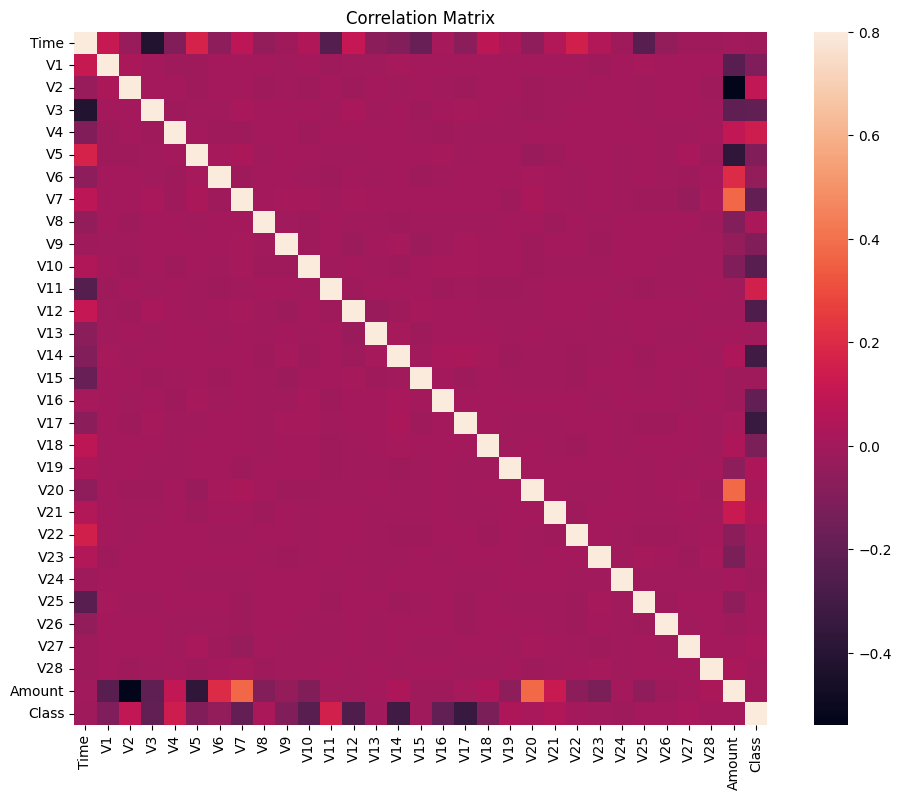

In [ ]:
# Correlation matrix
corrmat = data.corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corrmat, vmax=0.8, square=True)
plt.title('Correlation Matrix')
plt.show()

**Data Preprocessing**

In [ ]:
from sklearn.utils import resample

# Undersample the legitimate data to match the size of fraud data
legit_sample = resample(valid,
                        replace=False,  # Without replacement
                        n_samples=len(fraud),  # Match number of fraud samples
                        random_state=42)  # For reproducibility

# Combine balanced samples
balanced_data = pd.concat([legit_sample, fraud]).sample(frac=1, random_state=42)

# Split features and target from balanced data
X_balanced = balanced_data.drop(['Class'], axis=1)
Y_balanced = balanced_data['Class']

# Verify the class distribution in the balanced dataset
print("Balanced class distribution:")
print(balanced_data['Class'].value_counts())
print(balanced_data.head())
print(balanced_data.tail())

Balanced class distribution:
Class
0.0    472
1.0    472
Name: count, dtype: int64
            Time        V1        V2        V3        V4        V5        V6  \
182182  125295.0  1.566420 -0.412388  0.251596  3.533538 -0.356729  1.413951   
46320    42729.0 -0.341652  1.416506  1.225974  1.875994  0.592953 -0.719916   
154668  102480.0 -1.929597  4.066413 -4.865184  5.898602 -0.552493 -1.555962   
45571    42407.0  1.145130  0.260346  0.762396  1.181412 -0.321464 -0.240291   
161121  113900.0  1.658431 -0.586805 -1.431464  0.293609  0.740478  0.988532   

              V7        V8        V9  ...       V21       V22       V23  \
182182 -0.951528  0.513277 -0.291929  ...  0.343517  0.529715  0.124598   
46320   1.228531 -0.182096 -1.586679  ...  0.063984  0.089848 -0.248549   
154668 -3.833623  0.679512 -3.463765  ...  1.137212  0.674245 -0.531765   
45571  -0.106471  0.006605  0.042087  ... -0.153159 -0.414724  0.130108   
161121  0.100681  0.180110  0.415771  ... -0.057136 -0.057756

#splitting the data

In [ ]:
from sklearn.model_selection import train_test_split

xTrain, xTest, yTrain, yTest =train_test_split(X_balanced, Y_balanced, test_size=0.2, random_state=42, stratify=Y_balanced)
print(Y_balanced.value_counts())

Class
0.0    472
1.0    472
Name: count, dtype: int64


#Training and Evaluating the Random Forest Model

              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98        95
         1.0       0.99      0.97      0.98        94

    accuracy                           0.98       189
   macro avg       0.98      0.98      0.98       189
weighted avg       0.98      0.98      0.98       189

AUC-ROC Score: 0.9930
Accuracy: 0.9788, Precision: 0.9891, Recall: 0.9681, F1-Score: 0.9785, MCC: 0.9579


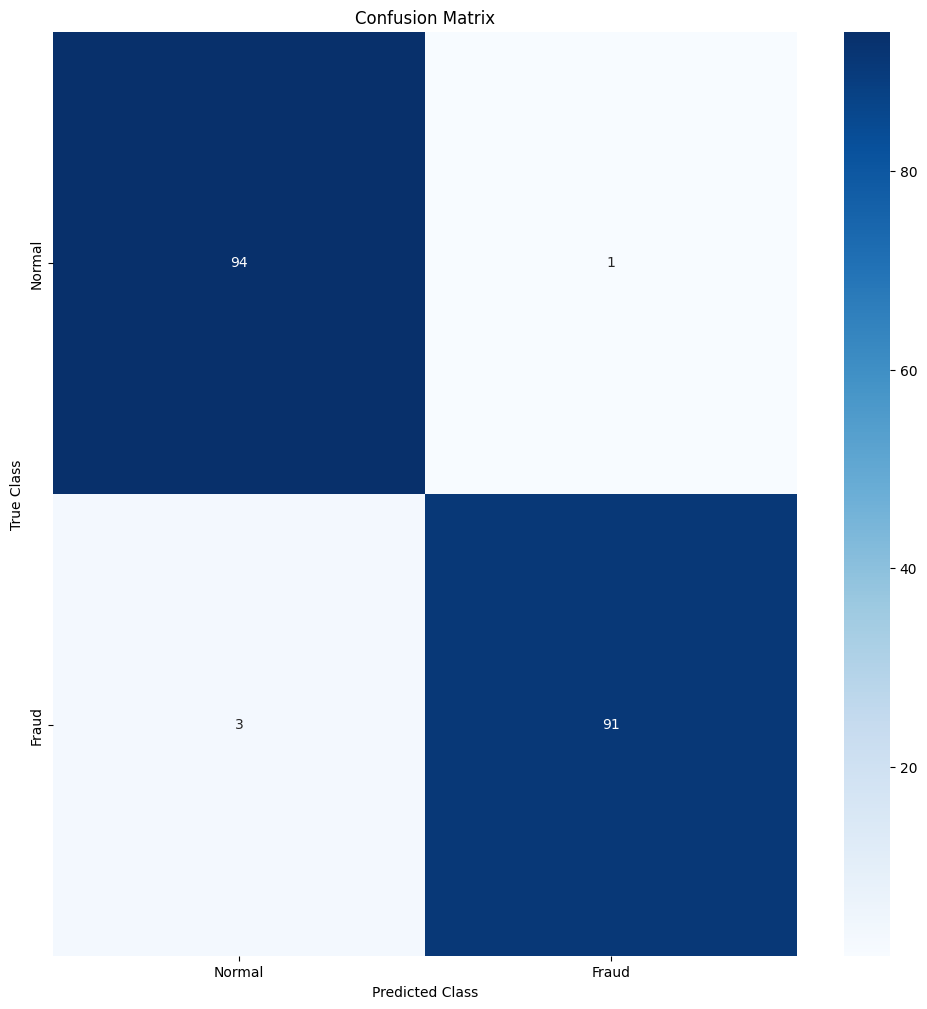

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix

# Apply SMOTE for oversampling
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
xTrain_resampled, yTrain_resampled = smote.fit_resample(xTrain, yTrain)

# Define and train the model on resampled data
rfc = RandomForestClassifier(random_state=42, class_weight='balanced')
rfc.fit(xTrain_resampled, yTrain_resampled)

# Predict and evaluate
y_pred = rfc.predict(xTest)
y_pred_proba = rfc.predict_proba(xTest)[:, 1]

# Print classification report
print(classification_report(yTest, y_pred))

# Print AUC-ROC Score
print(f"AUC-ROC Score: {roc_auc_score(yTest, y_pred_proba):.4f}")

# Print additional metrics
acc = accuracy_score(yTest, y_pred)
prec = precision_score(yTest, y_pred)
rec = recall_score(yTest, y_pred)
f1 = f1_score(yTest, y_pred)
MCC = matthews_corrcoef(yTest, y_pred)

print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1-Score: {f1:.4f}, MCC: {MCC:.4f}")

# Confusion Matrix
LABELS = ['Normal', 'Fraud']
conf_matrix = confusion_matrix(yTest, y_pred)
plt.figure(figsize=(12, 12))
sns.heatmap(conf_matrix, annot=True, fmt='d', xticklabels=LABELS, yticklabels=LABELS, cmap='Blues')
plt.title("Confusion Matrix")
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()


#Making Predictions with the Model

In [ ]:
import joblib
from sklearn.preprocessing import StandardScaler

# Assuming `xTrain` is the data you used to train your model, fit the scaler on it
scaler = StandardScaler()
xTrain_scaled = scaler.fit_transform(xTrain)

# Train the Random Forest classifier
rfc = RandomForestClassifier(random_state=42, class_weight='balanced')
rfc.fit(xTrain_resampled, yTrain_resampled)

# Save the model
joblib.dump(rfc, 'random_forest_model.pkl')

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

Doing Testing by giving two different inputs

In [ ]:
import joblib
from sklearn.preprocessing import StandardScaler

# Load the trained Random Forest classifier and scaler
rfc = joblib.load('random_forest_model.pkl')  # Update with the correct path to your saved model
scaler = joblib.load('scaler.pkl')  # Update with the correct path to your saved scaler

# Input data
input_data = {
     "Time": 128471.0,
    "V1": 0.909123838691231,
    "V2": 1.33765782444144,
    "V3": -4.48472766746064,
    "V4": 3.24535764512838,
    "V5": -0.417808776149092,
    "V6": -0.762118684149486,
    "V7": -2.5063487752776,
    "V8": 0, "V9": 0, "V10": 0, "V11": 0, "V12": 0, "V13": 0, "V14": 0,
    "V15": 0, "V16": 0, "V17": 0, "V18": 0, "V19": 0, "V20": 0,
    "V21": 0, "V22": 0, "V23": 0, "V24": 0, "V25": 0, "V26": 0,
    "V27": 0, "V28": 0, "Amount": 67.9
}

# Convert input data to a DataFrame
input_data_df = pd.DataFrame([input_data])

# Scale the input data
input_data_df_scaled = pd.DataFrame(scaler.transform(input_data_df), columns=input_data_df.columns)

# Ensure the feature order matches the training data
input_data_df_scaled = input_data_df_scaled[[col for col in rfc.feature_names_in_]]

# Predict probabilities
y_pred_proba = rfc.predict_proba(input_data_df_scaled)[:, 1]

# Adjust the threshold for classification
threshold = 0.2  # Lower threshold to increase sensitivity to fraud
prediction = (y_pred_proba >= threshold).astype(int)

# Output the result
if prediction[0] == 0:
    print("The transaction is not fraudulent.")
else:
    print("The transaction is fraudulent.")


The transaction is not fraudulent.


In [ ]:
import joblib
from sklearn.preprocessing import StandardScaler

# Load the trained Random Forest classifier and scaler
rfc = joblib.load('random_forest_model.pkl')  # Update with the correct path to your saved model
scaler = joblib.load('scaler.pkl')  # Update with the correct path to your saved scaler

# Input data
input_data = {
     "Time": 5,
    "V1": 166,
    "V2": 72,
    "V3": 19,
    "V4": 175,
    "V5": 25.8,
    "V6": 0.587,
    "V7": 53,
    "V8": 0, "V9": 0, "V10": 0, "V11": 0, "V12": 0, "V13": 0, "V14": 0,
    "V15": 0, "V16": 0, "V17": 0, "V18": 0, "V19": 0, "V20": 0,
    "V21": 0, "V22": 0, "V23": 0, "V24": 0, "V25": 0, "V26": 0,
    "V27": 0, "V28": 0, "Amount": 10
}

# Convert input data to a DataFrame
input_data_df = pd.DataFrame([input_data])

# Scale the input data
input_data_df_scaled = pd.DataFrame(scaler.transform(input_data_df), columns=input_data_df.columns)

# Ensure the feature order matches the training data
input_data_df_scaled = input_data_df_scaled[[col for col in rfc.feature_names_in_]]

# Predict probabilities
y_pred_proba = rfc.predict_proba(input_data_df_scaled)[:, 1]

# Adjust the threshold for classification
threshold = 0.2  # Lower threshold to increase sensitivity to fraud
prediction = (y_pred_proba >= threshold).astype(int)

# Output the result
if prediction[0] == 0:
    print("The transaction is not fraudulent.")
else:
    print("The transaction is fraudulent.")


The transaction is fraudulent.
